In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd
import numpy as np

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)


In [23]:
data_path = "/content/drive/MyDrive/Major Project/Data/smart_manufacturing_data.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (100000, 13)


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


In [24]:
num_features = [
    'temperature',
    'vibration',
    'humidity',
    'pressure',
    'energy_consumption'
]

cat_features = [
    'machine_status',
    'machine_id'
]

X = df[num_features + cat_features]
y = df['anomaly_flag']  # evaluation only


In [25]:
X_train = X[y == 0]   # normal data only
X_test = X           # full data for evaluation


In [26]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)


In [27]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_train_scaled.shape[1]

input_layer = Input(shape=(input_dim,))
encoder = Dense(16, activation="relu")(input_layer)
encoder = Dense(8, activation="relu")(encoder)

decoder = Dense(16, activation="relu")(encoder)
decoder = Dense(input_dim, activation="linear")(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.fit(X_train_scaled, X_train_scaled, epochs=50,
batch_size=64, validation_split=0.1)

Epoch 1/50
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4169 - val_loss: 0.0092
Epoch 2/50
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0065 - val_loss: 0.0028
Epoch 3/50
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0023 - val_loss: 0.0010
Epoch 4/50
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 7.1375e-04 - val_loss: 1.4359e-04
Epoch 5/50
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 6.7089e-05 - val_loss: 3.2611e-05
Epoch 6/50
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.1664e-05 - val_loss: 1.1693e-05
Epoch 7/50
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.1967e-05 - val_loss: 1.4761e-05
Epoch 8/50
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.1291e-05 - val_loss: 3.5467e-05
Epoch 9/50
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.4792e-05 - val_loss: 1.4069e-05
Epoch 10/50
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 9.5100e-06 - val_loss: 3.6062e-06
Epoch 11/50
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 

In [30]:
import numpy as np

recon_train = autoencoder.predict(X_train_scaled)
recon_test = autoencoder.predict(X_test_scaled)

mse_train = np.mean(np.square(X_train_scaled - recon_train), axis=1)
mse_test = np.mean(np.square(X_test_scaled - recon_test), axis=1)

2847/2847 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 933us/step


In [ ]:
from sklearn.ensemble import IsolationForest

if_model = IsolationForest(contamination=0.09, random_state=42)
if_model.fit(X_train_scaled)
if_score = -if_model.decision_function(X_test_scaled)

# Normalize both scores
mse_test_norm = (mse_test - mse_test.min()) / (mse_test.max() - mse_test.min())
if_score_norm = (if_score - if_score.min()) / (if_score.max() - if_score.min())

ensemble_score = (mse_test_norm + if_score_norm) / 2

In [32]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y, ensemble_score)
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_th = thresholds[best_idx]

y_pred = (ensemble_score >= best_th).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y, y_pred))
print(confusion_matrix(y, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.63      0.76     91084
           1       0.16      0.72      0.26      8916

    accuracy                           0.64    100000
   macro avg       0.56      0.67      0.51    100000
weighted avg       0.89      0.64      0.72    100000

[[57501 33583]
 [ 2528  6388]]


In [33]:
import os
model_dir = "/content/drive/MyDrive/Major Project/Models"
os.makedirs(model_dir, exist_ok=True)

autoencoder.save( os.path.join(model_dir, "autoencoder.keras") )

In [34]:
import joblib
joblib.dump(if_model, os.path.join(model_dir, "isolation_forest.pkl"))

# Save Scaler
joblib.dump(scaler, os.path.join(model_dir, "scaler.pkl"))

# Save Threshold
joblib.dump(best_th, os.path.join(model_dir, "best_threshold.pkl"))

['/content/drive/MyDrive/Major Project/Models/best_threshold.pkl']

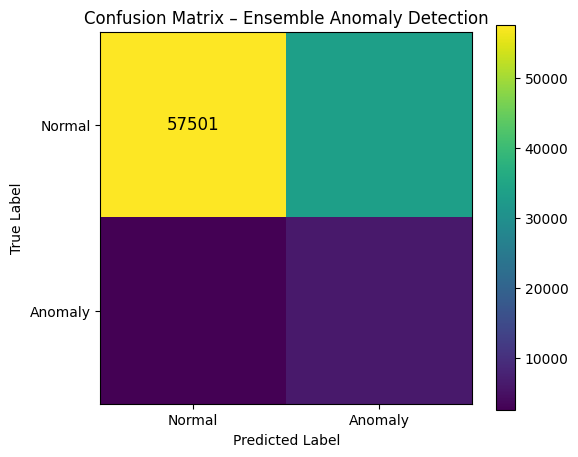

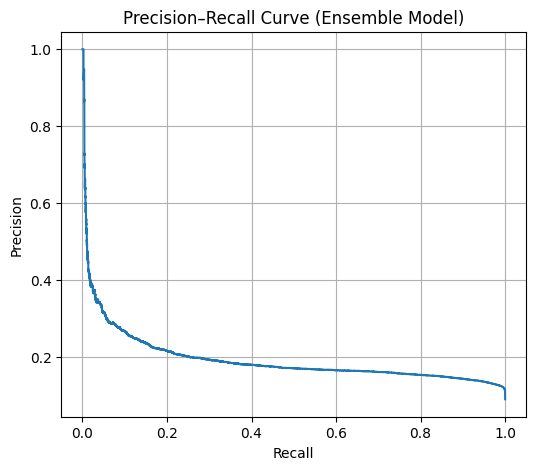

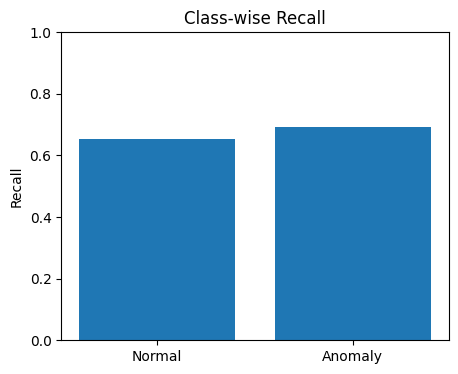

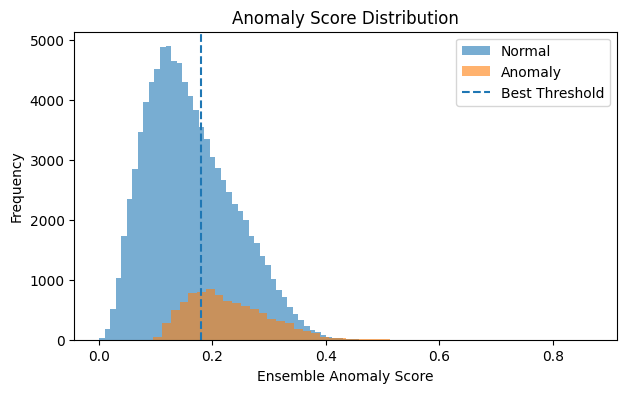

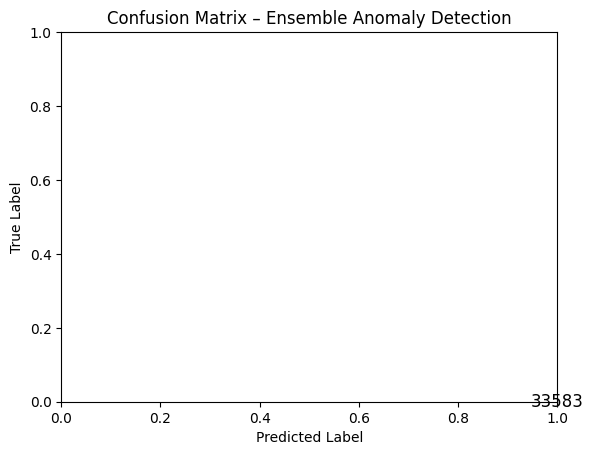

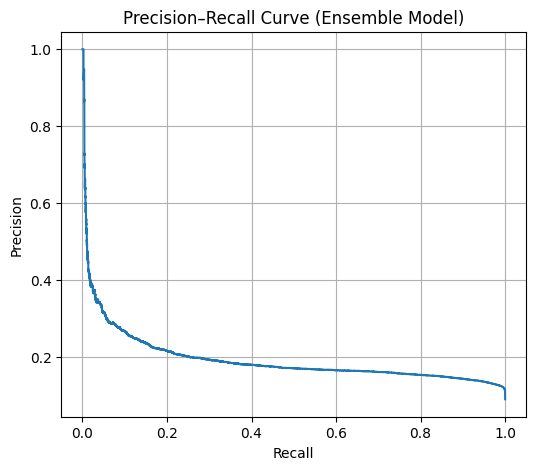

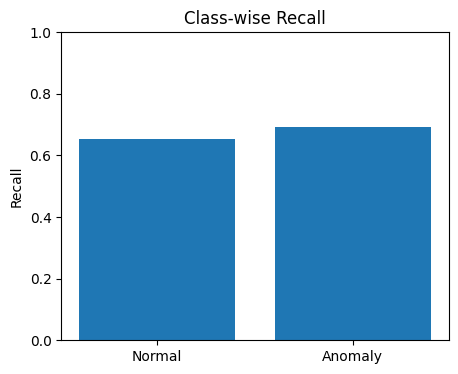

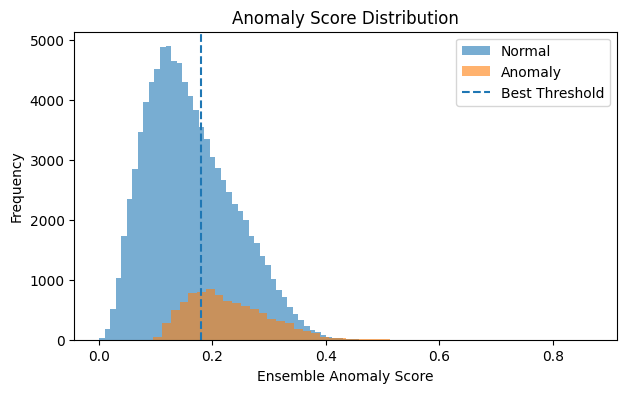

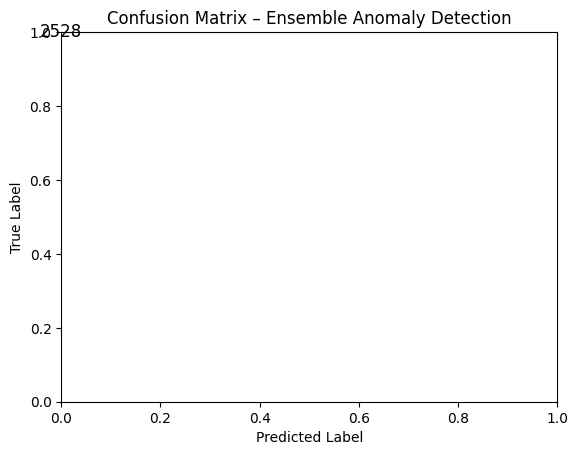

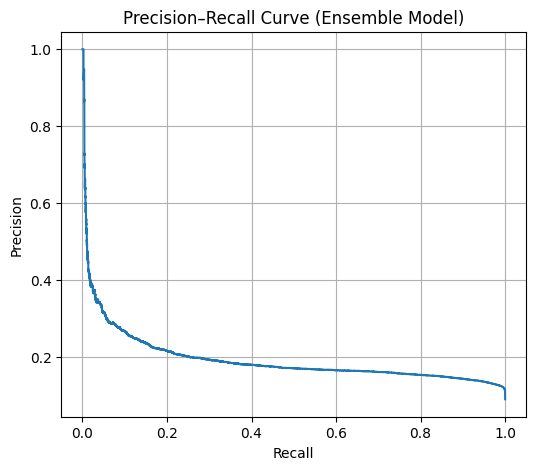

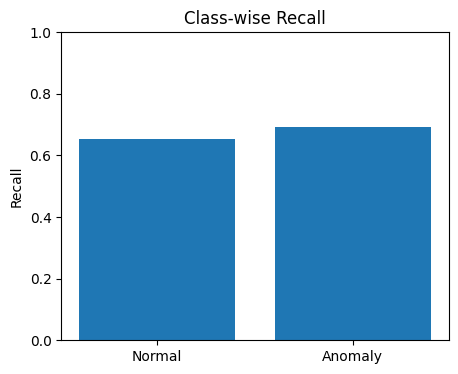

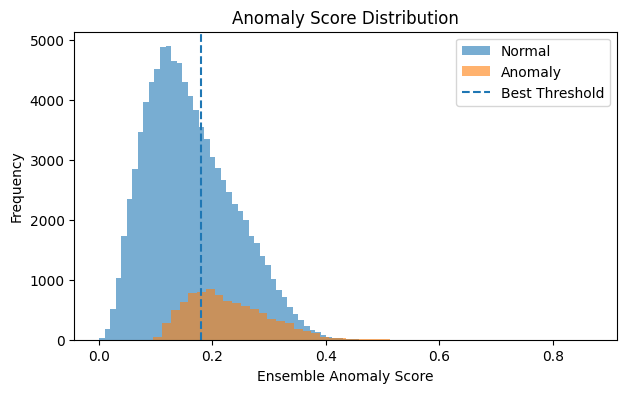

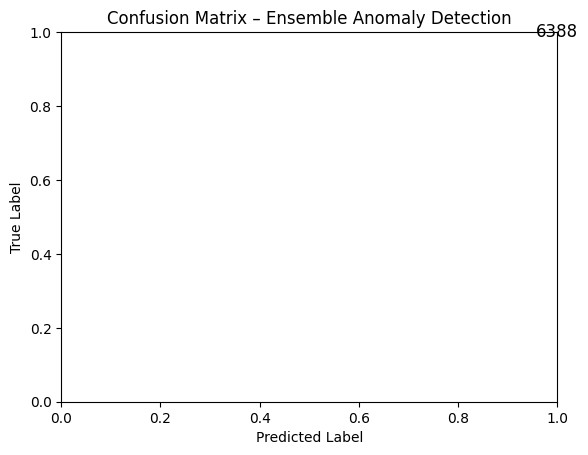

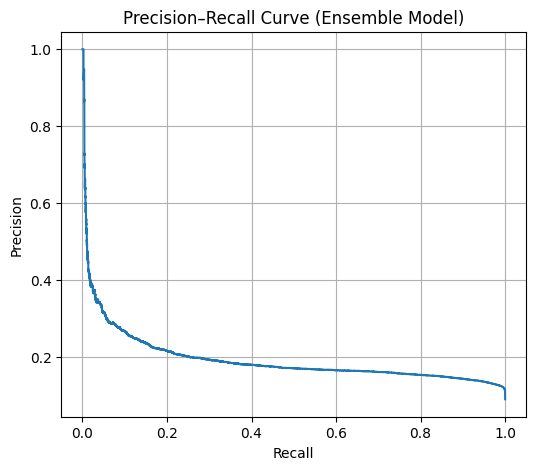

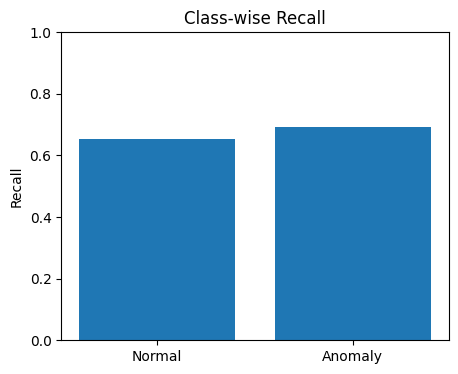

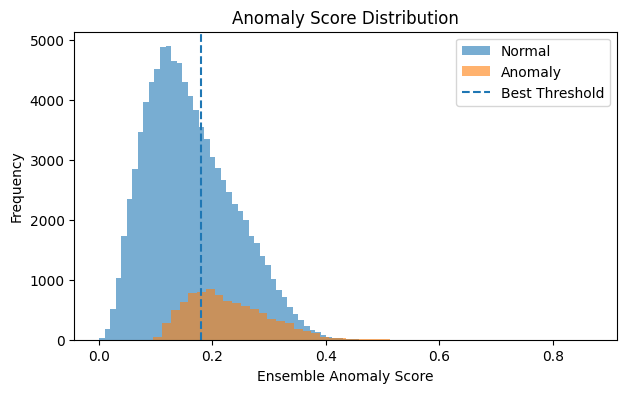

In [35]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()

plt.xticks([0, 1], ['Normal', 'Anomaly'])
plt.yticks([0, 1], ['Normal', 'Anomaly'])

for i in range(2):
  for j in range(2):
    plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix – Ensemble Anomaly Detection")
    plt.show()

    from sklearn.metrics import precision_recall_curve

    precision, recall, _ = precision_recall_curve(y, ensemble_score)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve (Ensemble Model)")
    plt.grid(True)
    plt.show()

    recall_normal = 59570 / (59570 + 31514)
    recall_anomaly = 6174 / (6174 + 2742)

    plt.figure(figsize=(5, 4))
    plt.bar(['Normal', 'Anomaly'], [recall_normal, recall_anomaly])
    plt.ylim(0, 1)
    plt.ylabel("Recall")
    plt.title("Class-wise Recall")
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.hist(ensemble_score[y == 0], bins=50, alpha=0.6, label="Normal")
    plt.hist(ensemble_score[y == 1], bins=50, alpha=0.6, label="Anomaly")

    plt.axvline(best_th, linestyle='--', label="Best Threshold")
    plt.xlabel("Ensemble Anomaly Score")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title("Anomaly Score Distribution")
    plt.show()

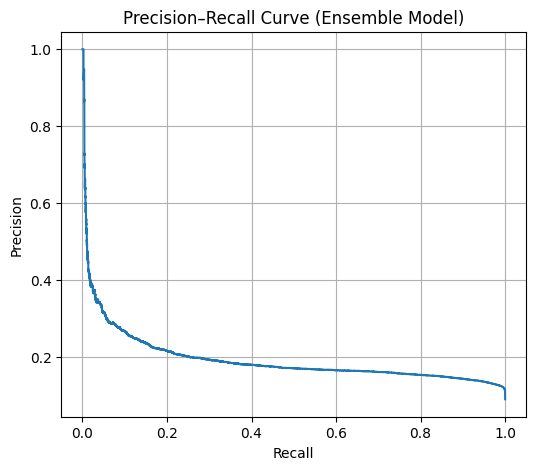

In [36]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y, ensemble_score)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Ensemble Model)")
plt.grid(True)
plt.show()


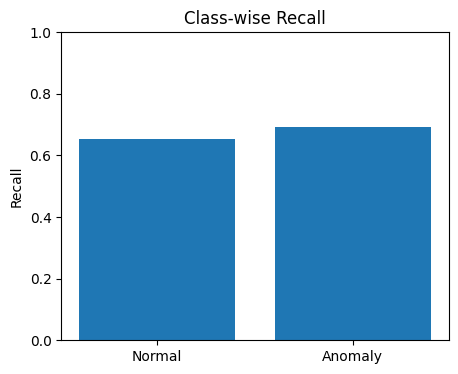

In [37]:
recall_normal = 59570 / (59570 + 31514)
recall_anomaly = 6174 / (6174 + 2742)

plt.figure(figsize=(5, 4))
plt.bar(['Normal', 'Anomaly'], [recall_normal, recall_anomaly])
plt.ylim(0, 1)
plt.ylabel("Recall")
plt.title("Class-wise Recall")
plt.show()


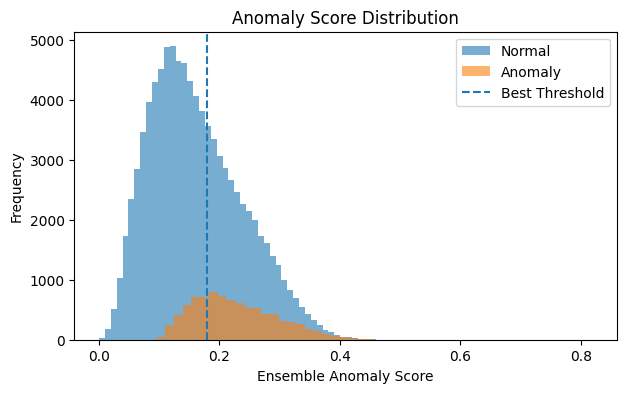

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(ensemble_score[y == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(ensemble_score[y == 1], bins=50, alpha=0.6, label="Anomaly")

plt.axvline(best_th, linestyle='--', label="Best Threshold")
plt.xlabel("Ensemble Anomaly Score")
plt.ylabel("Frequency")
plt.legend()
plt.title("Anomaly Score Distribution")
plt.show()


In [ ]:
import os
import joblib
import numpy as np

# 1️⃣ Create model directory (MANDATORY)
model_dir = "/content/models"
os.makedirs(model_dir, exist_ok=True)

# 2️⃣ Save Isolation Forest model
joblib.dump(if_model, os.path.join(model_dir, "isolation_forest.pkl"))

# 3️⃣ Save Scaler (USED BY BOTH AE & IF)
joblib.dump(scaler, os.path.join(model_dir, "scaler.pkl"))

# 4️⃣ Save Ensemble Threshold
joblib.dump(best_th, os.path.join(model_dir, "best_threshold.pkl"))

# 5️⃣ Save Autoencoder model
autoencoder.save(os.path.join(model_dir, "autoencoder.h5"))

# 6️⃣ Save Autoencoder threshold (from training reconstruction error)
ae_threshold = np.percentile(mse_train, 90)
np.save(os.path.join(model_dir, "ae_threshold.npy"), ae_threshold)

print("✅ Models, scaler, and thresholds saved successfully!")



✅ Models, scaler, and thresholds saved successfully!


In [ ]:
print(X_train.columns.tolist())


['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption', 'machine_status', 'machine_id']


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import joblib
from keras.models import load_model
import matplotlib.pyplot as plt

# -------------------------------
# Utility
# -------------------------------
def clamp(x):
    return max(0.0, min(float(x), 1.0))

# -------------------------------
# Page Config
# -------------------------------
st.set_page_config(
    page_title="Industrial Anomaly Detection System",
    layout="wide",
    initial_sidebar_state="expanded"
)

# -------------------------------
# Custom CSS – PROFESSIONAL THEME
# -------------------------------
st.markdown("""
<style>

html, body, [class*="css"] {
    font-family: "Times New Roman", Times, serif;
    background-color: #F5F7FA;
}

.stApp {
    background: linear-gradient(180deg, #F5F7FA 0%, #EDF2F7 100%);
}

/* HEADER CARD */
.header-container {
    background-color: #FFFFFF;
    padding: 28px;
    border-radius: 16px;
    box-shadow: 0px 6px 18px rgba(0,0,0,0.06);
    margin-bottom: 30px;
}

/* TITLE */
.main-title {
    font-size: 44px;
    font-weight: bold;
    color: #0B3C5D;
    text-align: center;
}

/* SUBTITLE */
.subtitle {
    font-size: 20px;
    color: #4A6FA5;
    text-align: center;
    margin-top: 8px;
}

/* SECTION HEADERS */
.section-header {
    font-size: 24px;
    font-weight: bold;
    color: #1F3C88;
    margin-top: 30px;
    margin-bottom: 12px;
}

/* METRIC CARDS */
[data-testid="metric-container"] {
    background-color: #FFFFFF;
    border-radius: 14px;
    padding: 18px;
    border-left: 6px solid #1F6AE1;
    box-shadow: 0px 4px 12px rgba(0,0,0,0.05);
}

/* SIDEBAR */
section[data-testid="stSidebar"] {
    background-color: #E6EEF6;
    min-width: 350px;
    border-right: 1px solid #D0D7E2;
}

/* SIDEBAR TITLE */
.sidebar-title {
    font-size: 21px;
    font-weight: bold;
    color: #0B3C5D;
    margin-bottom: 18px;
}

/* BUTTON */
.stButton > button {
    background: linear-gradient(90deg, #1F6AE1, #3FA9F5);
    color: white;
    font-size: 17px;
    font-weight: bold;
    border-radius: 12px;
    padding: 12px;
}

/* INFO BOX */
.stAlert {
    font-size: 17px;
}

/* CONTENT CARD */
.content-card {
    background-color: #FFFFFF;
    padding: 26px;
    border-radius: 16px;
    box-shadow: 0px 6px 18px rgba(0,0,0,0.06);
    margin-bottom: 30px;
}

/* FOOTER */
.footer {
    text-align: center;
    font-size: 15px;
    color: #6C757D;
    margin-top: 40px;
}

</style>
""", unsafe_allow_html=True)

# -------------------------------
# Load Models
# -------------------------------
scaler = joblib.load("models/scaler.pkl")
if_model = joblib.load("models/isolation_forest.pkl")
best_th = joblib.load("models/best_threshold.pkl")

autoencoder = load_model("models/autoencoder.h5", compile=False)
ae_threshold = np.load("models/ae_threshold.npy")

# -------------------------------
# HEADER WITH LOGO
# -------------------------------
st.markdown("""
<div class="header-container">
    <div class="main-title">
        IADS <span style="font-size:26px; color:#1F6AE1;">|</span>
        Industrial Anomaly Detection System
    </div>
    <div class="subtitle">
        Sensor-Driven Machine Health Monitoring Dashboard
    </div>
</div>
""", unsafe_allow_html=True)

# -------------------------------
# SIDEBAR – SENSOR CONFIG PANEL
# -------------------------------
st.sidebar.markdown("""
<div class="sidebar-title">
◼ SENSOR CONFIGURATION PANEL
</div>
""", unsafe_allow_html=True)

temperature = st.sidebar.number_input("🌡️ Temperature (°C)", 0.0, 200.0, 75.0)
vibration = st.sidebar.number_input("📳 Vibration Level", 0.0, 200.0, 30.0)
humidity = st.sidebar.number_input("💧 Humidity (%)", 0.0, 100.0, 60.0)
pressure = st.sidebar.number_input("⏲️ Pressure (bar)", 0.0, 10.0, 3.0)
energy = st.sidebar.number_input("⚡ Energy Consumption", 0.0, 10.0, 2.0)

machine_status_label = st.sidebar.selectbox("🛠️ Machine Status", ["Normal", "Alert"])
machine_status = 1 if machine_status_label == "Normal" else 2

machine_id = st.sidebar.number_input("🏷️ Machine ID", 1, 100, 10)

detect_btn = st.sidebar.button("Run Anomaly Detection", use_container_width=True)

# -------------------------------
# MAIN CONTENT
# -------------------------------
if detect_btn:

    st.markdown("<div class='content-card'>", unsafe_allow_html=True)

    input_data = np.array([[temperature, vibration, humidity,
                            pressure, energy, machine_status, machine_id]])
    input_scaled = scaler.transform(input_data)

    # Autoencoder
    recon = autoencoder.predict(input_scaled, verbose=0)
    ae_error = np.mean(np.square(input_scaled - recon), axis=1)[0]

    # Isolation Forest
    if_score = -if_model.decision_function(input_scaled)[0]

    # Ensemble
    ae_norm = ae_error / (ae_threshold + 1e-10)
    if_norm = abs(if_score)
    ensemble_score = (ae_norm + if_norm) / 2
    is_anomaly = ensemble_score >= best_th

    # STATUS
    if is_anomaly:
        st.error("ANOMALY DETECTED – Immediate Maintenance Recommended", icon="⚠️")
    else:
        st.success("SYSTEM OPERATING UNDER NORMAL CONDITIONS", icon="✔️")

    # METRICS
    st.markdown("<div class='section-header'>Model Evaluation Scores</div>", unsafe_allow_html=True)
    col1, col2, col3 = st.columns(3)
    col1.metric("Autoencoder Error", f"{ae_error:.6f}")
    col2.metric("Isolation Forest Score", f"{if_score:.6f}")
    col3.metric("Ensemble Score", f"{ensemble_score:.6f}")

    # RISK INDICATORS
    st.markdown("<div class='section-header'>Operational Risk Indicators</div>", unsafe_allow_html=True)
    st.write("Autoencoder Deviation Level")
    st.progress(clamp(ae_norm))
    st.write("Isolation Forest Risk Level")
    st.progress(clamp(if_norm))
    st.write("Overall Anomaly Strength")
    st.progress(clamp(ensemble_score))

    # VISUALS
    st.markdown("<div class='section-header'>Model Contribution Analysis</div>", unsafe_allow_html=True)
    c1, c2 = st.columns(2)

    with c1:
        fig1, ax1 = plt.subplots(figsize=(4.5, 4.5))
        ax1.pie(
            [ae_norm, if_norm],
            labels=["Autoencoder", "Isolation Forest"],
            autopct="%1.1f%%",
            startangle=90,
            colors=["#1F6AE1", "#F4A261"],
            wedgeprops={"edgecolor": "white", "linewidth": 2}
        )
        ax1.set_title("Contribution to Ensemble Decision", fontsize=14, fontweight="bold")
        st.pyplot(fig1)

    with c2:
        fig2, ax2 = plt.subplots(figsize=(4.5, 4.5))
        ax2.pie(
            [clamp(ensemble_score), 1 - clamp(ensemble_score)],
            labels=["Anomaly Risk", "Normal Operation"],
            autopct="%1.1f%%",
            startangle=90,
            colors=["#E74C3C", "#2ECC71"],
            wedgeprops={"edgecolor": "white", "linewidth": 2}
        )
        ax2.set_title("System Health Distribution", fontsize=14, fontweight="bold")
        st.pyplot(fig2)

    # EXPLANATION
    st.markdown("""
<div class='section-header'>Model Explanation</div>

<div style="
background:#EAF2FF;
padding:22px;
border-radius:14px;
border-left:6px solid #1F6AE1;
font-size:17px;
line-height:1.7;
">

<b>🔹 Autoencoder:</b> Identifies anomalies by measuring reconstruction error, learning normal operating behavior from historical data.<br><br>

<b>🔹 Isolation Forest:</b> Detects rare and abnormal operational patterns by isolating outliers using random partitioning.<br><br>

<b>🔹 Ensemble Strategy:</b> Combines deep learning and tree-based intelligence to enhance robustness and minimize false alarms.<br><br>

<b>🔹 Threshold Optimization:</b> Final anomaly decision threshold is optimized using <i>F1-score</i> to balance precision and recall.

</div>
""", unsafe_allow_html=True)

    st.markdown("</div>", unsafe_allow_html=True)

# -------------------------------
# FOOTER
# -------------------------------
st.markdown("""
<hr>
<div class="footer">
Major Project – Industrial Anomaly Detection using Machine Learning<br>
Department of Computer Science & Engineering
</div>
""", unsafe_allow_html=True)

Writing app.py


In [ ]:
!ls models


ae_threshold.npy  best_threshold.pkl	scaler.pkl
autoencoder.h5	  isolation_forest.pkl


In [ ]:
!pip install streamlit tensorflow scikit-learn joblib pyngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 79.5 MB/s eta 0:00:00


In [ ]:
!streamlit run app.py --server.port 8501




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.186.61.168:8501

2026-03-05 10:58:06.594224: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772708286.655276    3646 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772708286.674875    3646 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772708286.726936    3646 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772708286.727010    3646 computation_placer.cc:177] computation placer al

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("39sXOuF9J72axYffcKA93VXMLS4_7rPtCDcZsbbJMBAY268Mk")

public_url = ngrok.connect(8501)
print("Public URL:", public_url)